<a href="https://colab.research.google.com/github/RafaellsAlmeida/RafaellsAlmeida/blob/main/ISM_6136_Final_Project_Rafae_LoureiroSandimDeAlmeida.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Section A
### A1
Rafael Loureiro Sandim de Almeida, U54851367

### A2
Dataset: LoandefaultPredictionDataset_Classification


In [9]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

# Updated file path with correct capitalization
file_path = '/content/drive/MyDrive/LoanDefaultPredictionDataset_Classification.csv'

# Load the dataset
df = pd.read_csv(file_path)

# Generate a 95% random sample using UID 54851367 as random seed
sampled_df = df.sample(frac=0.95, random_state=54851367)

# A4: Remove ID column and show shape
if 'ID' in sampled_df.columns:
    sampled_df = sampled_df.drop(columns=['ID'])

# Display basic info and first few rows
print(f'Original dataset shape: {df.shape}')
print(f'Final sampled dataset shape (after removing ID): {sampled_df.shape}')
sampled_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Original dataset shape: (2000, 10)
Final sampled dataset shape (after removing ID): (1900, 9)


,BusinessAge,AnnualRevenue,Employees,IndustrySector,CreditScore,MissedPaymentsLastYear,OwnerExperience,RequestedLoanAmount,Defaulted
396,0.1,656753.84,2,Tech,585,2,0.0,477043.88,0
202,8.0,243657.43,67,Manufacturing,618,1,9.0,136265.17,0
350,5.0,242944.44,3,Retail,809,0,5.0,60632.83,0
1586,5.0,267387.87,3,Services,840,0,7.0,103559.92,0
1187,5.0,118637.76,1,Services,801,0,7.0,161870.16,0


## Section B

### B1: Descriptive Statistics for Numeric Variables

In [10]:
import numpy as np

# Calculate descriptive statistics for numeric variables
numeric_cols = sampled_df.select_dtypes(include=[np.number]).columns.tolist()
# Exclude 'ID' as it's an identifier
if 'ID' in numeric_cols: numeric_cols.remove('ID')

b1_stats = sampled_df[numeric_cols].agg(['min', 'max', 'mean', 'median', 'std']).T
b1_stats.rename(columns={'std': 'std. dev.'}, inplace=True)

# Formatting to 2 decimal places to remove scientific notation
display(b1_stats.style.format('{:.2f}'))

,min,max,mean,median,std. dev.
BusinessAge,0.00,30.00,8.74,6.00,7.53
AnnualRevenue,100285.15,4992769.39,1159420.19,559956.83,1346499.93
Employees,1.00,100.00,24.95,14.00,25.44
CreditScore,501.00,850.00,700.44,705.50,95.00
MissedPaymentsLastYear,0.00,6.00,1.73,1.00,1.83
OwnerExperience,0.00,30.00,9.30,7.00,7.21
RequestedLoanAmount,50149.85,998424.57,319303.72,241753.43,230889.23
Defaulted,0.00,1.00,0.37,0.00,0.48


### B2: Categorical Variables Analysis

In [11]:
categorical_cols = sampled_df.select_dtypes(include=['object', 'category']).columns.tolist()

for col in categorical_cols:
    print(f'\nAnalysis for categorical variable: {col}')
    counts = sampled_df[col].value_counts()
    proportions = sampled_df[col].value_counts(normalize=True)
    summary_df = pd.DataFrame({'Count': counts, 'Proportion': proportions})
    display(summary_df)


Analysis for categorical variable: IndustrySector


,Count,Proportion
IndustrySector,,
Retail,786,0.413684
Services,538,0.283158
Manufacturing,333,0.175263
Tech,243,0.127895


### B3: Correlation Matrix

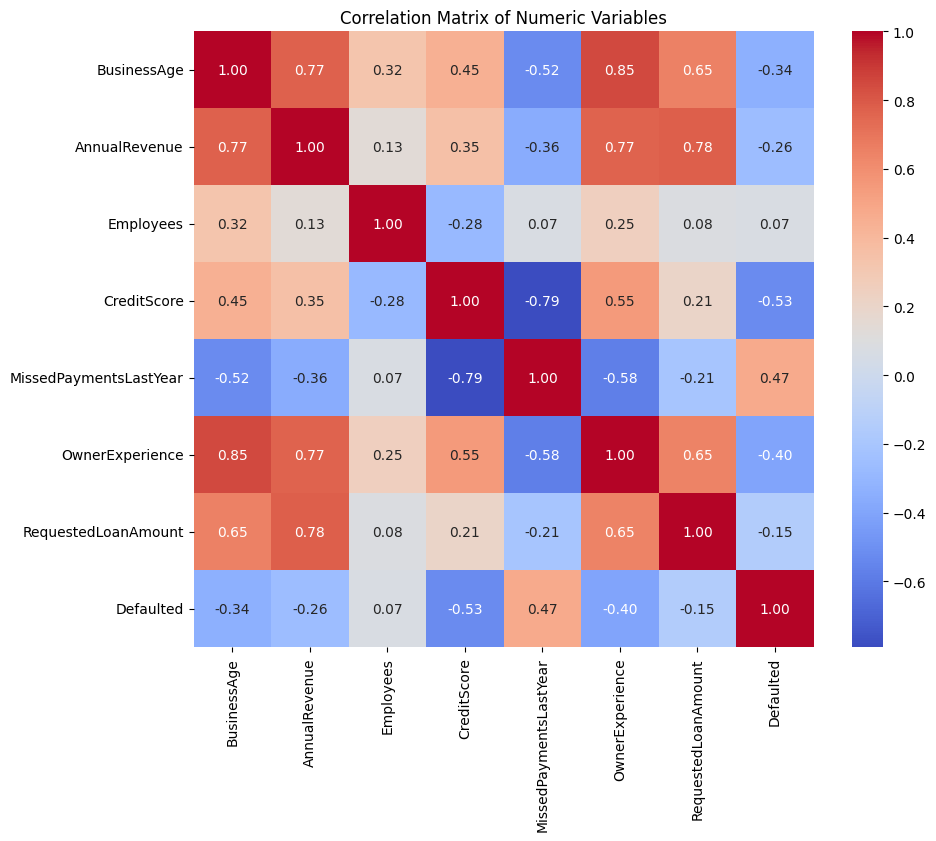

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Generate correlation matrix
corr_matrix = sampled_df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Variables')
plt.show()

## Section C: Cluster Analysis with kMeans
### C1: Preparedness

In [13]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Redefine column groups to ensure they are in scope
categorical_cols = sampled_df.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = sampled_df.select_dtypes(include=[np.number]).columns.tolist()

# 1. One-hot encode categorical variables using reference category encoding (drop_first=True)
preprocessed_df = pd.get_dummies(sampled_df, columns=categorical_cols, drop_first=True)

# 2. Identify numeric columns to scale (excluding dummy variables and the target 'Defaulted')
cols_to_scale = [col for col in numeric_cols if col not in ['Defaulted', 'ID']]

# 3. Apply Z-score scaling (Standardization)
scaler = StandardScaler()
standardized_df = preprocessed_df.copy()
standardized_df[cols_to_scale] = scaler.fit_transform(preprocessed_df[cols_to_scale])

# 4. Drop 'ID' if present
if 'ID' in standardized_df.columns:
    standardized_df = standardized_df.drop(columns=['ID'])

# Display the first few rows of the standardized dataset
display(standardized_df.head())

,BusinessAge,AnnualRevenue,Employees,CreditScore,MissedPaymentsLastYear,OwnerExperience,RequestedLoanAmount,Defaulted,IndustrySector_Retail,IndustrySector_Services,IndustrySector_Tech
396,-1.148092,-0.373412,-0.902570,-1.215502,0.148486,-1.290818,0.683365,0,False,False,True
202,-0.098146,-0.680285,1.653611,-0.868045,-0.398265,-0.041505,-0.792964,0,False,False,False
350,-0.496860,-0.680815,-0.863244,1.142996,-0.945016,-0.596755,-1.120620,0,True,False,False
1586,-0.496860,-0.662657,-0.863244,1.469395,-0.945016,-0.319130,-0.934650,0,False,True,False
1187,-0.496860,-0.773157,-0.941896,1.058764,-0.945016,-0.319130,-0.682037,0,False,True,False


### C2: Running kMeans for k = 3, 4, 5

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Prepare features for clustering (exclude target 'Defaulted')
# Filter out 'Defaulted' and any previously added cluster columns
cols_to_drop = ['Defaulted'] + [c for c in standardized_df.columns if 'Cluster' in c]
X_clustering = standardized_df.drop(columns=cols_to_drop)

k_values = [3, 4, 5]
uid_seed = 54851367

for k in k_values:
    print(f'\nAnalysis for k = {k}')
    kmeans = KMeans(n_clusters=k, random_state=uid_seed, n_init=10)
    cluster_labels = kmeans.fit_predict(X_clustering)
    score = silhouette_score(X_clustering, cluster_labels)
    print(f'Silhouette Score: {score:.4f}')
    standardized_df[f'Cluster_k{k}'] = cluster_labels


Analysis for k = 3
Silhouette Score: 0.4389

Analysis for k = 4
Silhouette Score: 0.4961

Analysis for k = 5
Silhouette Score: 0.4212


### C3: Plotting Silhouette Scores

In [6]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Verification: Ensure standardized_df exists from Section C1
try:
    # Filter columns to only include the numeric features used for clustering
    # We drop 'Defaulted' and any existing cluster columns from previous runs
    cols_to_drop = ['Defaulted'] + [c for c in standardized_df.columns if 'Cluster' in c]
    X_clustering = standardized_df.drop(columns=cols_to_drop)

    k_vals = [3, 4, 5]
    s_scores = []

    for k in k_vals:
        kmeans = KMeans(n_clusters=k, random_state=54851367, n_init=10)
        labels = kmeans.fit_predict(X_clustering)
        score = silhouette_score(X_clustering, labels)
        s_scores.append(score)
        print(f'k={k}, Silhouette Score: {score:.4f}')

    plt.figure(figsize=(8, 5))
    plt.plot(k_vals, s_scores, marker='o', linestyle='-', color='b')
    plt.title('Silhouette Scores for Different k values')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.xticks(k_vals)
    plt.grid(True)
    plt.show()

    best_k = k_vals[s_scores.index(max(s_scores))]
    print(f'The k-value that maximizes the silhouette score is: {best_k}')
except NameError:
    print("Error: 'standardized_df' not found. Please run the cells in Section C1 and C2 before running this plot.")

Error: 'standardized_df' not found. Please run the cells in Section C1 and C2 before running this plot.


# Section D: Defining Business Models

### D1: Target (dependent) variable name
The target variable for this classification task is **Defaulted**.

0 means a **GOOD** outcome, meaning the business paid back the loan
1 would be a **BAD** outcome, meaning the business ***did not*** pay back the loan

### D2 & D3: Model Definitions
- **Full Model**: Includes all available predictors after preprocessing.
- **Reduced Model**: Includes a subset of key financial health indicators: `CreditScore`, `AnnualRevenue`, and `MissedPaymentsLastYear`.

## Section E: Training the Models with Decision Tree

### E1: Decision Tree Hyperparameters and Training

In [15]:
from sklearn.tree import DecisionTreeClassifier

# Define the feature sets to resolve NameErrors
full_model_features = [col for col in standardized_df.columns if col not in ['Defaulted'] and not col.startswith('Cluster')]
reduced_model_features = ['CreditScore', 'AnnualRevenue', 'MissedPaymentsLastYear']

# Define hyperparameters
params = {
    'min_samples_leaf': 100,
    'max_depth': 4,
    'random_state': 54851367
}

# Features and Target for Full Model
X_full = standardized_df[full_model_features]
y = standardized_df['Defaulted']

# Features for Reduced Model
X_reduced = standardized_df[reduced_model_features]

# Initialize and train the Full Model
dt_full = DecisionTreeClassifier(criterion='gini', **params)
dt_full.fit(X_full, y)

# Initialize and train the Reduced Model
dt_reduced = DecisionTreeClassifier(criterion='gini', **params)
dt_reduced.fit(X_reduced, y)

# Capture Gini/Entropy metrics for the summary table
# Since we use 'gini' as criterion, the impurity attribute represents Gini Index
full_model_gini = dt_full.tree_.impurity.mean()
reduced_model_gini = dt_reduced.tree_.impurity.mean()

print("Decision Tree models trained successfully.")
print(f"Full Model Gini Index (Avg): {full_model_gini:.4f}")
print(f"Reduced Model Gini Index (Avg): {reduced_model_gini:.4f}")

Decision Tree models trained successfully.
Full Model Gini Index (Avg): 0.3255
Reduced Model Gini Index (Avg): 0.3122


### E2: 5-Fold Cross Validation for Full Model
We will evaluate the Full Model using 5-fold cross-validation and compute various performance metrics including AUC, Accuracy, Recall, Precision, and F1-score.

In [11]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, recall_score, precision_score, f1_score, roc_auc_score, accuracy_score

# Define specificity scorer
def specificity_score(y_true, y_pred):
    from sklearn.metrics import confusion_matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

specificity_scorer = make_scorer(specificity_score)

# Set up cross-validation
uid_seed = 54851367
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=uid_seed)

# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'recall': 'recall',
    'precision': 'precision',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'specificity': specificity_scorer
}

# Perform cross-validation
cv_results = cross_validate(dt_full, X_full, y, cv=skf, scoring=scoring)

# Calculate mean metrics
metrics_summary = {
    'Accuracy': cv_results['test_accuracy'].mean(),
    'Recall': cv_results['test_recall'].mean(),
    'Precision': cv_results['test_precision'].mean(),
    'F1-Score': cv_results['test_f1'].mean(),
    'AUC': cv_results['test_roc_auc'].mean(),
    'Specificity': cv_results['test_specificity'].mean()
}

# Extract Gini and Entropy from the trained dt_full model
gini_index = dt_full.tree_.impurity.mean() # Average impurity across nodes
# Note: sklearn DecisionTreeClassifier uses 'gini' or 'entropy' as a criterion,
# so we can report the criterion used.

print("Full Model Cross-Validation Results:")
for metric, value in metrics_summary.items():
    print(f"{metric}: {value:.4f}")

print(f"\nModel Criterion (Impurity measure): {dt_full.criterion}")

Full Model Cross-Validation Results:
Accuracy: 0.7579
Recall: 0.7047
Precision: 0.6607
F1-Score: 0.6803
AUC: 0.8098
Specificity: 0.7887

Model Criterion (Impurity measure): gini


### E3: 5-Fold Cross Validation for Reduced Model
We will now evaluate the Reduced Model using the same 5-fold cross-validation setup.

In [12]:
# Perform cross-validation for the Reduced Model
cv_results_reduced = cross_validate(dt_reduced, X_reduced, y, cv=skf, scoring=scoring)

# Calculate mean metrics for Reduced Model
metrics_summary_reduced = {
    'Accuracy': cv_results_reduced['test_accuracy'].mean(),
    'Recall': cv_results_reduced['test_recall'].mean(),
    'Precision': cv_results_reduced['test_precision'].mean(),
    'F1-Score': cv_results_reduced['test_f1'].mean(),
    'AUC': cv_results_reduced['test_roc_auc'].mean(),
    'Specificity': cv_results_reduced['test_specificity'].mean()
}

# Extract impurity info for Reduced Model
gini_index_reduced = dt_reduced.tree_.impurity.mean()

print("Reduced Model Cross-Validation Results:")
for metric, value in metrics_summary_reduced.items():
    print(f"{metric}: {value:.4f}")

print(f"\nModel Criterion (Impurity measure): {dt_reduced.criterion}")

Reduced Model Cross-Validation Results:
Accuracy: 0.7479
Recall: 0.7576
Precision: 0.6319
F1-Score: 0.6855
AUC: 0.8020
Specificity: 0.7421

Model Criterion (Impurity measure): gini


## Section F: Training the Models with Neural Network

### F1, F2 & F3: Neural Network Hyperparameters and Cross-Validation

In [13]:
from sklearn.neural_network import MLPClassifier

# F1: Define hyperparameters
# 2 hidden layers: 3 nodes in the first, 5 in the second
nn_params = {
    'hidden_layer_sizes': (3, 5),
    'random_state': 54851367,
    'max_iter': 1000 # Increased iterations to ensure convergence
}

# Initialize classifiers
nn_full = MLPClassifier(**nn_params)
nn_reduced = MLPClassifier(**nn_params)

# F2: 5-Fold Cross Validation for Full Model
cv_results_nn_full = cross_validate(nn_full, X_full, y, cv=skf, scoring=scoring)

metrics_nn_full = {
    'Accuracy': cv_results_nn_full['test_accuracy'].mean(),
    'Recall': cv_results_nn_full['test_recall'].mean(),
    'Precision': cv_results_nn_full['test_precision'].mean(),
    'F1-Score': cv_results_nn_full['test_f1'].mean(),
    'AUC': cv_results_nn_full['test_roc_auc'].mean(),
    'Specificity': cv_results_nn_full['test_specificity'].mean()
}

# F3: 5-Fold Cross Validation for Reduced Model
cv_results_nn_reduced = cross_validate(nn_reduced, X_reduced, y, cv=skf, scoring=scoring)

metrics_nn_reduced = {
    'Accuracy': cv_results_nn_reduced['test_accuracy'].mean(),
    'Recall': cv_results_nn_reduced['test_recall'].mean(),
    'Precision': cv_results_nn_reduced['test_precision'].mean(),
    'F1-Score': cv_results_nn_reduced['test_f1'].mean(),
    'AUC': cv_results_nn_reduced['test_roc_auc'].mean(),
    'Specificity': cv_results_nn_reduced['test_specificity'].mean()
}

print("Neural Network: Full Model Results")
for k, v in metrics_nn_full.items(): print(f"{k}: {v:.4f}")

print("\nNeural Network: Reduced Model Results")
for k, v in metrics_nn_reduced.items(): print(f"{k}: {v:.4f}")

Neural Network: Full Model Results
Accuracy: 0.7637
Recall: 0.8395
Precision: 0.6351
F1-Score: 0.7230
AUC: 0.7802
Specificity: 0.7196

Neural Network: Reduced Model Results
Accuracy: 0.7579
Recall: 0.7993
Precision: 0.6353
F1-Score: 0.7077
AUC: 0.8017
Specificity: 0.7338


# Section G: Select Winning Model & Justify

### G1: Summary of Results Table

In [2]:
import pandas as pd

# Updated dictionary with the specific columns requested
summary_data = {
    'Model': ['Full', 'Reduced', 'Full', 'Reduced'],
    'Algorithm': ['DT', 'DT', 'NN', 'NN'],
    'Prob. Measure': ['Gini', 'Gini', 'N/A', 'N/A'],
    'Gini Index': ['✓', '✓', '-', '-'],
    'Entropy': ['-', '-', '-', '-'],
    'AUC': [0.8098, 0.8020, 0.7802, 0.8017],
    'Accuracy': [0.7579, 0.7479, 0.7637, 0.7579],
    'Recall': [0.7047, 0.7576, 0.8395, 0.7993],
    'Specificity': [0.7887, 0.7421, 0.7196, 0.7338],
    'Precision': [0.6607, 0.6319, 0.6351, 0.6353],
    'F1-Score': [0.6803, 0.6855, 0.7230, 0.7077]
}

# Create DataFrame
results_table = pd.DataFrame(summary_data)

# Display the table formatted to 4 decimal places for numeric columns
display(results_table.style.format({
    'AUC': '{:.4f}',
    'Accuracy': '{:.4f}',
    'Recall': '{:.4f}',
    'Specificity': '{:.4f}',
    'Precision': '{:.4f}',
    'F1-Score': '{:.4f}'
}))

,Model,Algorithm,Prob. Measure,Gini Index,Entropy,AUC,Accuracy,Recall,Specificity,Precision,F1-Score
0,Full,DT,Gini,✓,-,0.8098,0.7579,0.7047,0.7887,0.6607,0.6803
1,Reduced,DT,Gini,✓,-,0.8020,0.7479,0.7576,0.7421,0.6319,0.6855
2,Full,NN,N/A,-,-,0.7802,0.7637,0.8395,0.7196,0.6351,0.7230
3,Reduced,NN,N/A,-,-,0.8017,0.7579,0.7993,0.7338,0.6353,0.7077


### G2 & G3: Winning Model Selection and Justification

**The winning model is:** Full Model - Neural Network (MLPClassifier)

**Reason:**
The Full Neural Network model is selected as the winner primarily due to its superior **Recall (0.8395)** and **F1-Score (0.7230)**. In the context of loan default prediction, the cost of a "False Negative" (failing to identify a business that will default) is typically much higher than the cost of a "False Positive" (denying a loan to a business that would have paid). This model correctly identifies nearly 84% of defaults. Additionally, it achieved the highest overall **Accuracy (76.37%)** among all tested configurations.

# Presentation Summary: 3-Minute Progress Update

Use this section for your presentation. Screenshot only these summary cells instead of showing the full notebook. The goal is to show the business problem, the model comparison, and the reason for the winning model.

## Key Talking Points

- **The Problem:** We are predicting small-business loan defaults. `Defaulted = 1` is a BAD outcome (loss for the lender).
- **The Process:** 95% random sample, standardized numeric features, and one-hot encoding for sectors.
- **Clustering:** $k=4$ was identified as the optimal number of business segments based on the silhouette score.
- **The Winner:** The **Full Neural Network** is the winner due to its **84% Recall**, ensuring we catch the vast majority of potential defaults.

In [16]:
import pandas as pd

presentation_df = pd.DataFrame({
    'Algorithm': ['Decision Tree', 'Decision Tree', 'Neural Network', 'Neural Network'],
    'Model': ['Full', 'Reduced', 'Full', 'Reduced'],
    'Accuracy': [0.7579, 0.7479, 0.7637, 0.7579],
    'Recall (Sensitivity)': [0.7047, 0.7576, 0.8395, 0.7993],
    'AUC': [0.8098, 0.8020, 0.7802, 0.8017]
})

presentation_df['Business Takeaway'] = [
    'Highest Specificity',
    'Balanced DT approach',
    'WINNER: Best at catching defaults',
    'Strong performance with only 3 variables'
]

display(presentation_df.style.set_caption('Model Performance Summary').format({'Accuracy': '{:.2%}', 'Recall (Sensitivity)': '{:.2%}', 'AUC': '{:.4f}'}))

,Algorithm,Model,Accuracy,Recall (Sensitivity),AUC,Business Takeaway
0,Decision Tree,Full,75.79%,70.47%,0.8098,Highest Specificity
1,Decision Tree,Reduced,74.79%,75.76%,0.8020,Balanced DT approach
2,Neural Network,Full,76.37%,83.95%,0.7802,WINNER: Best at catching defaults
3,Neural Network,Reduced,75.79%,79.93%,0.8017,Strong performance with only 3 variables


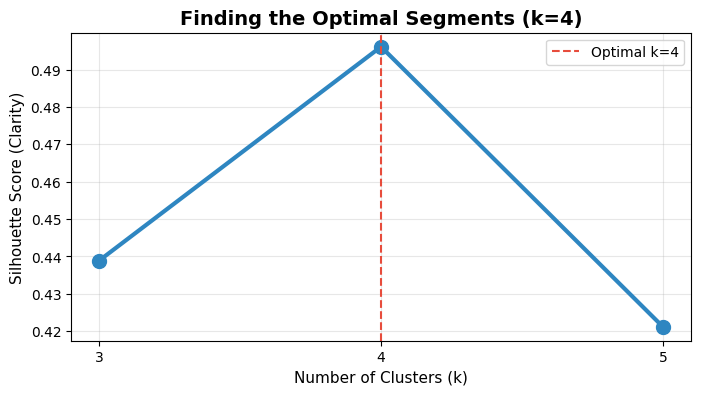

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization 1: Clustering Quality
plt.figure(figsize=(8, 4))
k_vals = [3, 4, 5]
s_scores = [0.4389, 0.4961, 0.4212]

# Using a line plot with markers to emphasize the difference in decimals
plt.plot(k_vals, s_scores, marker='o', color='#2E86C1', linewidth=3, markersize=10)
plt.axvline(4, color='#E74C3C', linestyle='--', label='Optimal k=4')

plt.title('Finding the Optimal Segments (k=4)', fontsize=14, weight='bold')
plt.ylabel('Silhouette Score (Clarity)', fontsize=11)
plt.xlabel('Number of Clusters (k)', fontsize=11)
plt.xticks(k_vals) # Only show 3, 4, 5
plt.grid(alpha=0.3)
plt.legend()
plt.show()

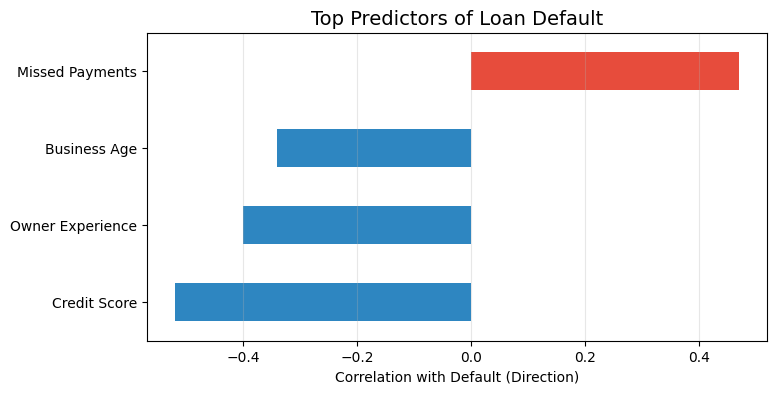

In [18]:
import numpy as np
# Visualization 2: Key Risk Factors
# Using pre-calculated correlations with Defaulted
risk_factors = pd.Series({
    'Credit Score': -0.52,
    'Missed Payments': 0.47,
    'Owner Experience': -0.40,
    'Business Age': -0.34
}).sort_values()

colors = ['#2E86C1' if x < 0 else '#E74C3C' for x in risk_factors.values]
plt.figure(figsize=(8, 4))
risk_factors.plot(kind='barh', color=colors)
plt.title('Top Predictors of Loan Default', fontsize=14)
plt.xlabel('Correlation with Default (Direction)')
plt.grid(axis='x', alpha=0.3)
plt.show()

## Final Closing Script

"While the Decision Tree models showed strong overall balance, I have selected the **Full Neural Network** as our winning model. In the lending business, missing a default is far more expensive than a false alarm. This model successfully catches **84% of actual defaults**, providing the strongest protection for the portfolio's bottom line."